# Medical Image Classification using Deep Learning
## Chest X-Ray Pneumonia Detection Project

In [1]:
# ============================================
# Step 1 - Install KaggleHub
# ============================================

!pip install -q kagglehub

In [2]:
# ============================================
# Step 2 - Configure Kaggle API Token
# ============================================

import os

# Replace with your Kaggle API token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_28210c6823a8e005da191261de85b96a"

print("Kaggle token configured successfully!")

Kaggle token configured successfully!


In [3]:
# ============================================
# Step 3 - Download Dataset
# ============================================

import kagglehub

dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset Path:", dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path: /kaggle/input/chest-xray-pneumonia


In [4]:
# ============================================
# Step 4 - Access Dataset Directory
# ============================================

import os

dataset_path = dataset_path + "/chest_xray/chest_xray"

print(os.listdir(dataset_path))

['val', '.DS_Store', 'test', 'train']


In [5]:
# ============================================
# Step 5 - Import Required Libraries
# ============================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision.datasets import ImageFolder

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.10.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [6]:
# ============================================
# Step 6 - Image Preprocessing
# ============================================

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Transforms created successfully!")

Transforms created successfully!


In [7]:
# ============================================
# Step 7 - Define Dataset Paths
# ============================================

train_path = dataset_path + "/train"
test_path = dataset_path + "/test"
val_path = dataset_path + "/val"

print("Train Path:", train_path)
print("Test Path:", test_path)
print("Validation Path:", val_path)

Train Path: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
Test Path: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
Validation Path: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val


In [8]:
# ============================================
# Step 8 - Load and Re-Split Datasets
# ============================================

# Load original training dataset
original_train_dataset = ImageFolder(
    root=train_path,
    transform=train_transform
)

# Load original validation dataset
original_val_dataset = ImageFolder(
    root=val_path,
    transform=train_transform
)

# Keep test dataset unchanged
test_dataset = ImageFolder(
    root=test_path,
    transform=test_transform
)

# Merge original train and validation datasets
combined_dataset = ConcatDataset([
    original_train_dataset,
    original_val_dataset
])

# Create new split sizes
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size

# Create new train and validation datasets
train_dataset, val_dataset = random_split(
    combined_dataset,
    [train_size, val_size]
)

print("New Training Size:", len(train_dataset))
print("New Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))


New Training Size: 4185
New Validation Size: 1047
Test Size: 624


In [9]:
# ============================================
# Step 9 - Create DataLoaders
# ============================================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


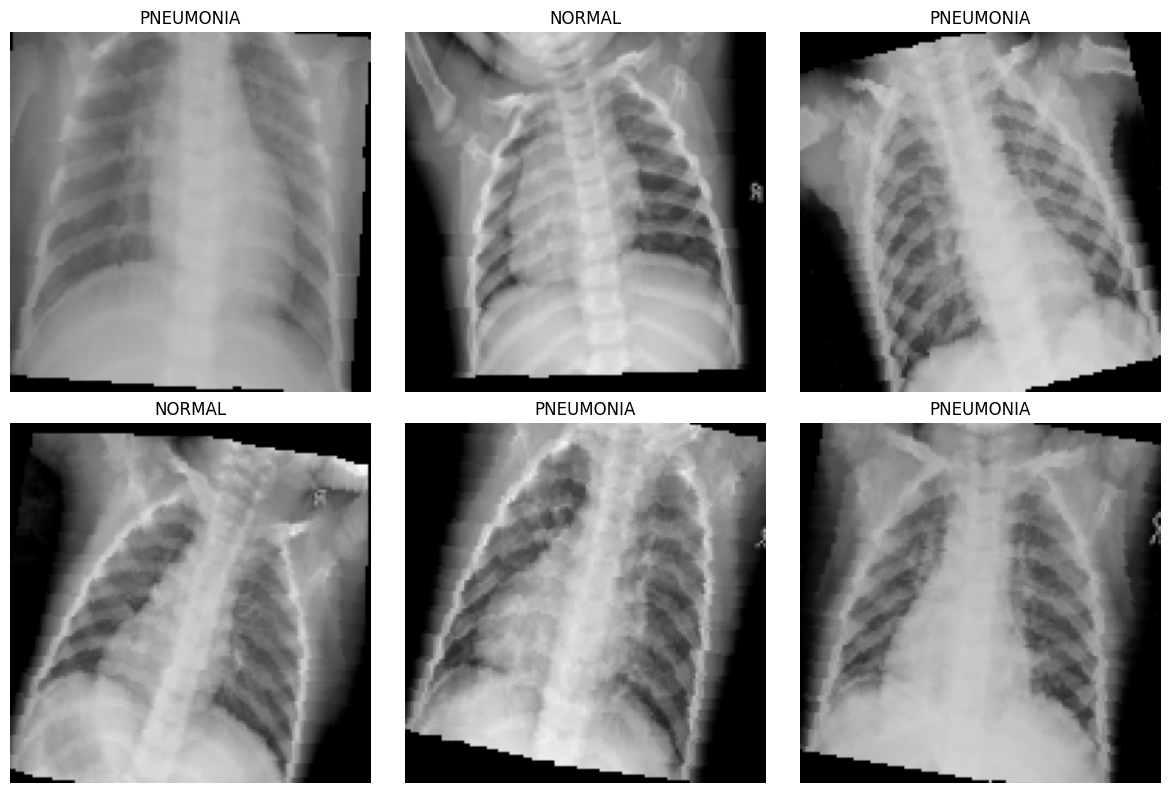

In [11]:
# ============================================
# Step 10 - Visualize Sample Images
# ============================================

images, labels = next(iter(train_loader))

class_names = original_train_dataset.classes

plt.figure(figsize=(12, 8))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    image = images[i].permute(1, 2, 0)

    image = image * 0.5 + 0.5

    plt.imshow(image)

    plt.title(class_names[labels[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# Step 11 - Configure Device
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [13]:
# ============================================
# Step 12 - Build Baseline CNN Model
# ============================================

class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.relu4 = nn.ReLU()

        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):

        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.relu4(self.fc1(x))

        x = self.fc2(x)

        return x

model_a = SimpleCNN().to(device)

print(model_a)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


In [14]:
# ============================================
# Step 13 - Loss Function and Optimizer
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer_a = optim.Adam(
    model_a.parameters(),
    lr=0.001
)

In [15]:
# ============================================
# Step 14 - Training Function
# ============================================

def train_model(model, train_loader, val_loader,
                criterion, optimizer, epochs=10):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_accuracy = 100 * correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)

        val_accuracy = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.2f}%")
        print("-" * 40)

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

In [16]:
# ============================================
# Step 15 - Train Baseline CNN
# ============================================

epochs = 10

(
    train_losses_a,
    val_losses_a,
    train_accuracies_a,
    val_accuracies_a
) = train_model(
    model=model_a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_a,
    epochs=epochs
)

Epoch [1/10]
Train Loss: 0.3435
Train Accuracy: 84.83%
Validation Loss: 0.1589
Validation Accuracy: 94.08%
----------------------------------------
Epoch [2/10]
Train Loss: 0.1511
Train Accuracy: 94.24%
Validation Loss: 0.1418
Validation Accuracy: 94.46%
----------------------------------------
Epoch [3/10]
Train Loss: 0.1456
Train Accuracy: 94.29%
Validation Loss: 0.1456
Validation Accuracy: 93.89%
----------------------------------------
Epoch [4/10]
Train Loss: 0.1183
Train Accuracy: 95.36%
Validation Loss: 0.1122
Validation Accuracy: 95.89%
----------------------------------------
Epoch [5/10]
Train Loss: 0.1112
Train Accuracy: 95.53%
Validation Loss: 0.1259
Validation Accuracy: 95.13%
----------------------------------------
Epoch [6/10]
Train Loss: 0.1075
Train Accuracy: 96.08%
Validation Loss: 0.1187
Validation Accuracy: 95.70%
----------------------------------------
Epoch [7/10]
Train Loss: 0.0949
Train Accuracy: 96.34%
Validation Loss: 0.1071
Validation Accuracy: 95.80%
-----

In [17]:
# ============================================
# Step 16 - Improved CNN Model
# ============================================

class ImprovedCNN(nn.Module):

    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(

            # First convolution block
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Second convolution block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Third convolution block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Fourth convolution block
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            # Fully connected layer
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),

            # Dropout layer
            nn.Dropout(0.6),

            # Output layer
            nn.Linear(256, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

model_b = ImprovedCNN().to(device)

print(model_b)


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [18]:
# ============================================
# Step 17 - Improved Model Optimizer
# ============================================

optimizer_b = optim.SGD(
    model_b.parameters(),
    lr=0.0001,
    momentum=0.9,
    weight_decay=1e-4
)


## Overfitting Reduction Improvements
This version includes:
- Dataset re-splitting
- Stronger augmentation
- Weight decay regularization
- Reduced model complexity
- Higher dropout

In [19]:
# ============================================
# Step 18 - Train Improved CNN
# ============================================

(
    train_losses_b,
    val_losses_b,
    train_accuracies_b,
    val_accuracies_b
) = train_model(
    model=model_b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_b,
    epochs=epochs
)

Epoch [1/10]
Train Loss: 0.4785
Train Accuracy: 76.82%
Validation Loss: 0.3497
Validation Accuracy: 87.30%
----------------------------------------
Epoch [2/10]
Train Loss: 0.3275
Train Accuracy: 84.95%
Validation Loss: 0.2777
Validation Accuracy: 88.16%
----------------------------------------
Epoch [3/10]
Train Loss: 0.2814
Train Accuracy: 87.50%
Validation Loss: 0.2369
Validation Accuracy: 90.93%
----------------------------------------
Epoch [4/10]
Train Loss: 0.2501
Train Accuracy: 89.46%
Validation Loss: 0.2271
Validation Accuracy: 91.50%
----------------------------------------
Epoch [5/10]
Train Loss: 0.2281
Train Accuracy: 90.80%
Validation Loss: 0.1919
Validation Accuracy: 92.45%
----------------------------------------
Epoch [6/10]
Train Loss: 0.2046
Train Accuracy: 92.04%
Validation Loss: 0.1904
Validation Accuracy: 92.26%
----------------------------------------
Epoch [7/10]
Train Loss: 0.1894
Train Accuracy: 92.69%
Validation Loss: 0.1600
Validation Accuracy: 94.56%
-----

In [20]:
# ============================================
# Step 19 - Evaluate Improved CNN
# ============================================

model_b.eval()

correct = 0
total = 0

test_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_b(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

improved_accuracy = 100 * correct / total
improved_loss = test_loss / len(test_loader)

print(f"Improved CNN Test Accuracy: {improved_accuracy:.2f}%")
print(f"Improved CNN Test Loss: {improved_loss:.4f}")

Improved CNN Test Accuracy: 79.97%
Improved CNN Test Loss: 0.4800


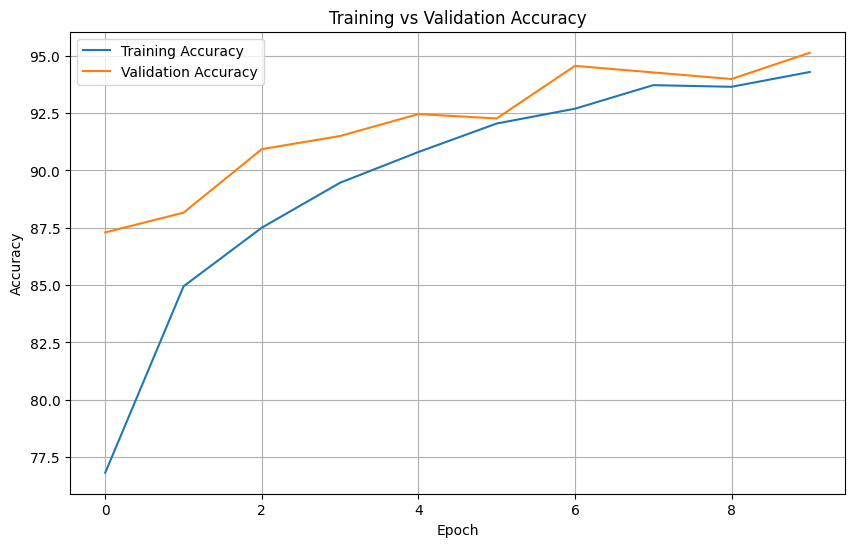

In [21]:
# ============================================
# Step 20 - Plot Accuracy Curves
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(train_accuracies_b, label='Training Accuracy')

plt.plot(val_accuracies_b, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid()

plt.show()

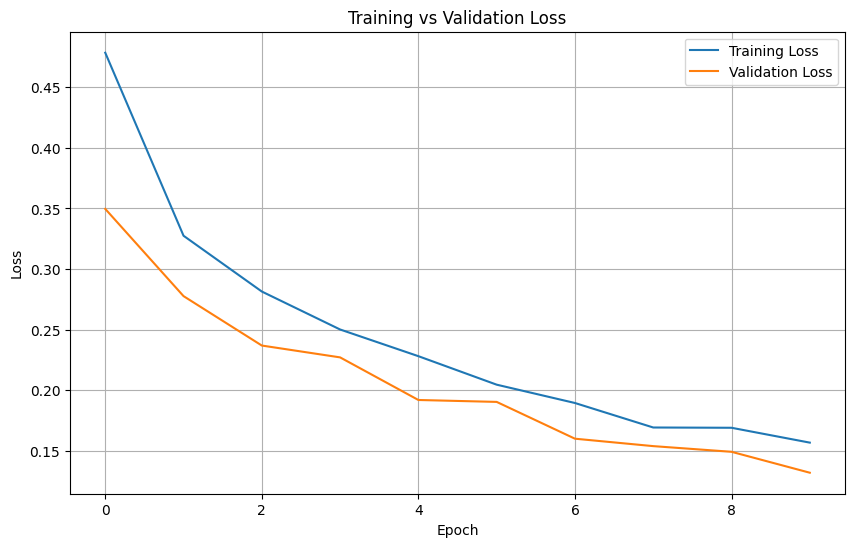

In [22]:
# ============================================
# Step 21 - Plot Loss Curves
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(train_losses_b, label='Training Loss')

plt.plot(val_losses_b, label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid()

plt.show()

In [23]:
# ============================================
# Step 22 - Final Results Comparison
# ============================================

print("=" * 60)
print("FINAL RESULTS COMPARISON")
print("=" * 60)

print(f"{'Model':<25} {'Accuracy':<15} {'Loss':<15}")
print("-" * 60)

print(f"{'Improved CNN':<25} {improved_accuracy:<15.2f} {improved_loss:<15.4f}")

FINAL RESULTS COMPARISON
Model                     Accuracy        Loss           
------------------------------------------------------------
Improved CNN              79.97           0.4800         
